# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: Ver PRADO.

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: <mark>ANDRÉS BORJA DURO</mark>



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Problema de Clasificación (5 puntos)**

## 1.1 Contexto: Clasificación de Gama de Móviles

Una empresa de tecnología quiere lanzar un nuevo modelo de teléfono móvil y necesita estimar en qué rango de precios colocarlo para competir en el mercado. Para ello, ha recopilado datos de ventas de diversos móviles con sus especificaciones técnicas.

**Objetivo:** Crear un modelo que clasifique un móvil en uno de los 4 rangos de precios basándose en sus características (RAM, batería, megapíxeles, etc.).

**Variable Objetivo (Target):**
- `price_range`: 0 (Bajo Coste), 1 (Coste Medio), 2 (Coste Alto), 3 (Coste Muy Alto).

**Principales Variables (Features):**
- `battery_power`: Energía total de batería en mAh.
- `ram`: Memoria de acceso aleatorio en Mb (suele ser la más determinante).
- `fc`: Megapíxeles de cámara frontal.
- `int_memory`: Memoria interna en Gb.
- `mobile_wt`: Peso del móvil.
- `touch_screen`: Si tiene pantalla táctil (1) o no (0).
- ... y otras especificaciones de hardware.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif


# Carga de datos Clasificación (Mobile Price)
url='https://drive.google.com/file/d/1qciBzxaCwRV-LO-zueyQlBcgxiQtM_eI/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clas = pd.read_csv(url)


print("Datos de Móviles cargados:")
display(df_clas.head())

Datos de Móviles cargados:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 1.2 Análisis Exploratorio de Datos (EDA) y Preprocesado

Realice las siguientes tareas obligatorias:

1.  **Análisis de Variables:** Estudie qué variables tienen mayor correlación con el `price_range`. ¿Es la RAM la más importante? Visualícelo.
2.  **Valores Nulos y Outliers:** Compruebe la limpieza del dataset.
3.  **Escalado de Datos:** Dado que tenemos variables con rangos muy distintos (ej: `battery_power` en miles vs `clock_speed` decimal), es **obligatorio** escalar las características (StandardScaler/MinMaxScaler).
4.  **Selección de Características:** (Opcional) Puede intentar reducir la dimensionalidad o eliminar variables con baja correlación (ej. `three_g` o `touch_screen` si no afectan al precio).

1.  **Análisis de Variables:**



In [2]:
matriz_corr = df_clas.corr() # Obtenemos la matriz de correlación
# Nos quedamos la correlacion con el precio y ordenamos de más correlacionados a menos
corr_price = matriz_corr['price_range'].sort_values(ascending = False)
print(corr_price)

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


Como se puede ver en la celda anterior, la correlacion nos da valores entre -1 y 1, y como era de esperar el precio está totalmente correlacionado consigo mismo por lo tanto tiene un 1. La más importante es la RAM ya que es la que mayor correlación tiene con el precio.

2.  **Valores Nulos y Outliers:**

In [3]:
df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

Tenemos 2000 teléfonos, y como se ve más abajo todas las columanas tienen 2000 valores no nulos, por tanto no hay ningún valor nulo en nuestros datos

In [4]:
df_clas.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


Hay algunos valores atípicos que pueden ser por ejemplo: <br>
- `fc` : El 75% de los móviles tiene 7 megapíxeles o menos, y la media general es 4.3. Sin embargo, el máximo llega hasta 19. Esto indica que hay algunos móviles muy específicos con cámaras frontales excepcionalmente potentes que se salen de la norma general.
- `px_height`: Sucede lo mismo que con fc.

También hay algunos valores sin mucho sentido como los minimos en px_height = 0 y sc_w = 0, que no pueden ser 0 ya que son la altura de la pantalla en pixeles y el ancho físico de la pantalla respectivamente.

3.  **Escalado de Datos:**

Para ello primero nos quedamos con todos los datos en bruto y tambien por separado con los precios

In [5]:
X_raw = df_clas.drop(columns=['price_range']).values   # Nos quedamos con todos los datos en bruto quitando el rango de precio
Y_raw = df_clas['price_range'].values
print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))
rangos= np.unique(Y_raw)
print("Hay {} rangos de precio: {}".format(len(rangos), rangos))

Dimensiones de X: 2000 datos y 20 atributos/dato
Hay 4 rangos de precio: [0 1 2 3]


Ahora separamos los datos de la siguiente forma 20% para tests y 80% para entrenamiento

In [6]:
# Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
# Hacemos esto ANTES del escalado para evitar fuga de información (data leakage)
X_train, X_test, y_train, y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=42, stratify=Y_raw) # satratify hace que haya el mismo porcentaje de cada rango de precio


Ahora sí vamos a proceder al escalado de datos

In [7]:
# Estandarización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos test con los parámetros de train

4.  **Selección de Características:** (Opcional)

Elegir características mediante Correlación o SelectKBest responde a dos enfoques distintos. La matriz de correlación busca exclusivamente relaciones lineales perfectas, lo que puede descartar variables que sean muy útiles pero cuya relación no forme una línea recta.

Por el contrario, SelectKBest (usando f_classif) se centra en la separación de grupos. Mide matemáticamente mediante estadística (ANOVA) si una variable permite aislar y distinguir claramente las distintas clases.

Internamente, evalúa cada columna de forma independiente, le asigna una puntuación según su capacidad de separar estas clases y se queda estrictamente con el top "K".

Por tanto voy a usar SelectKBest:<br>
Al final nos quedamos con los 4 mejores que son: `battery_power`, `px_height` , `px_width`, `ram`. En este caso salen las mismas que si lo hubieramos hecho con la matriz de correlación, ya que hay una gran brecha entre estas variables y las demás, como se demuestra en la matriz de correlación.

In [8]:
selector = SelectKBest(score_func=f_classif, k=4)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_seleccionado = selector.transform(X_test_scaled)

# Esto es solo para mostrar con que datos nos quedamos
mascara_ganadoras = selector.get_support()
nombres_columnas_X = df_clas.drop('price_range', axis=1).columns
nombres_elegidos = nombres_columnas_X[mascara_ganadoras]
print("Las 4 mejores características seleccionadas por el algoritmo son:")
print(nombres_elegidos.tolist())

Las 4 mejores características seleccionadas por el algoritmo son:
['battery_power', 'px_height', 'px_width', 'ram']


## 1.3 Entrenamiento y Validación (Clasificación Multiclase)

Pruebe al menos 2 modelos de clasificación (ej. KNN, Random Forest, SVM con kernel RBF).

- **Nota Importante:** Al ser un problema **multiclase** (4 clases), asegúrese de configurar las métricas adecuadamente (ej. `average='macro'` o `'weighted'`).
- **Métricas obligatorias:** Accuracy, Informe de Clasificación (Precision/Recall/F1 por clase) y Matriz de Confusión (Heatmap).

In [9]:
# DEFINIMOS LOS 2 MODELOS
modelo_rf = RandomForestClassifier(random_state=42)
modelo_svm = SVC(kernel='rbf', random_state=42) # SVM con kernel RBF

# SELECCIÓN DE MODELO (Validación Cruzada en TRAIN)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_rf = cross_val_score(modelo_rf, X_train_scaled, y_train, cv=skf, scoring='accuracy')
scores_svm = cross_val_score(modelo_svm, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("--- Resultados de Validación Cruzada (Precisión/Accuracy) ---")
print(f"Random Forest: {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})")
print(f"SVM (Kernel RBF): {scores_svm.mean():.4f} (+/- {scores_svm.std():.4f})\n")

--- Resultados de Validación Cruzada (Precisión/Accuracy) ---
Random Forest: 0.8631 (+/- 0.0301)
SVM (Kernel RBF): 0.8575 (+/- 0.0100)



Tras analizarlos parace un poco mejor el Random Forest, tiene un 0.86, sin embargo es  más inestable ya que tiene una desviación del +/-0.03, a diferencia del otro que tiene +/-0.01

--- MÉTRICAS OBLIGATORIAS EN TEST ---
Precisión final en el conjunto de prueba --> Random Forest: 88.00
Precisión final en el conjunto de prueba --> SVM (RBF): 89.50

Report de RANDOM FOREST:


,precision,recall,f1-score,support
0,0.95,0.96,0.96,100.00
1,0.82,0.84,0.83,100.00
2,0.81,0.79,0.80,100.00
3,0.93,0.93,0.93,100.00
accuracy,0.88,0.88,0.88,0.88
macro avg,0.88,0.88,0.88,400.00
weighted avg,0.88,0.88,0.88,400.00


Report de Accuracy SVM (RBF):


,precision,recall,f1-score,support
0,0.96,0.94,0.95,100.0
1,0.87,0.87,0.87,100.0
2,0.82,0.87,0.84,100.0
3,0.94,0.90,0.92,100.0
accuracy,0.90,0.90,0.90,0.9
macro avg,0.90,0.90,0.90,400.0
weighted avg,0.90,0.90,0.90,400.0


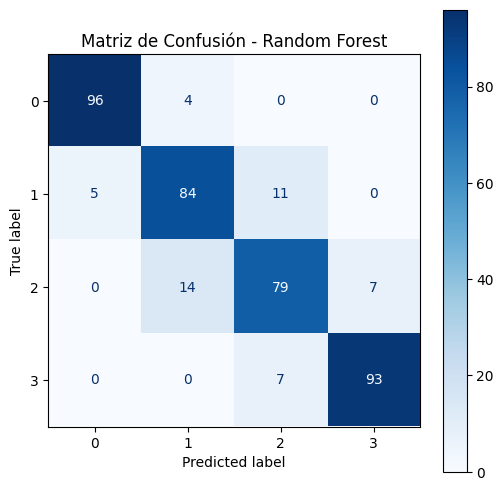

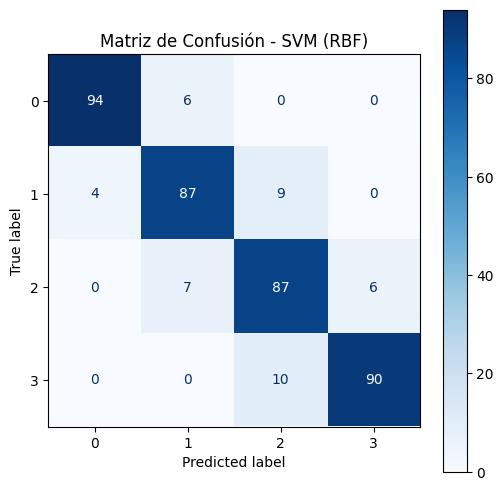

In [10]:
# EVALUACIÓN FINAL EN TEST (Las métricas obligatorias)
# Entrenamos ambos modelos con todo el Train y predecimos el Test
modelo_rf.fit(X_train_scaled, y_train)
y_pred_rf = modelo_rf.predict(X_test_scaled)

modelo_svm.fit(X_train_scaled, y_train)
y_pred_svm = modelo_svm.predict(X_test_scaled)

print("--- MÉTRICAS OBLIGATORIAS EN TEST ---")

# Accuracy
precision_final_rf = accuracy_score(y_test, y_pred_rf)
precision_final_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión final en el conjunto de prueba --> Random Forest: {precision_final_rf * 100:.2f}")
print(f"Precisión final en el conjunto de prueba --> SVM (RBF): {precision_final_svm * 100:.2f}\n")


# Informes de Clasificación (Incluyen Precision, Recall, F1 y los promedios macro/weighted)
report_final_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_final_svm = classification_report(y_test, y_pred_svm, output_dict=True)

print('Report de RANDOM FOREST:')
df_rf = pd.DataFrame(report_final_rf).transpose()
display(df_rf.round(2))

print('Report de Accuracy SVM (RBF):')
df_svm = pd.DataFrame(report_final_svm).transpose()
display(df_svm.round(2))


# Matrices de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rangos)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=rangos)


# Graficamos las matrices
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
disp_svm.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - SVM (RBF)')
plt.show()



**ENTRENAMIENTO CON DATOS FILTRADOS:**
Ahora lo entrenamos pero con los 4 mejores datos que hemos seleccionado anteriormente

--- MÉTRICAS OBLIGATORIAS EN TEST  (Usando 4 mejores datos) ---
Precisión final en el conjunto de prueba --> Random Forest: 94.00
Precisión final en el conjunto de prueba --> SVM (RBF): 95.75

Report de RANDOM FOREST:


,precision,recall,f1-score,support
0,0.97,0.99,0.98,100.00
1,0.93,0.91,0.92,100.00
2,0.89,0.91,0.90,100.00
3,0.97,0.95,0.96,100.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.94,0.94,0.94,400.00
weighted avg,0.94,0.94,0.94,400.00


Report de Accuracy SVM (RBF):


,precision,recall,f1-score,support
0,0.99,0.98,0.98,100.00
1,0.92,0.98,0.95,100.00
2,0.96,0.90,0.93,100.00
3,0.96,0.97,0.97,100.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,400.00
weighted avg,0.96,0.96,0.96,400.00


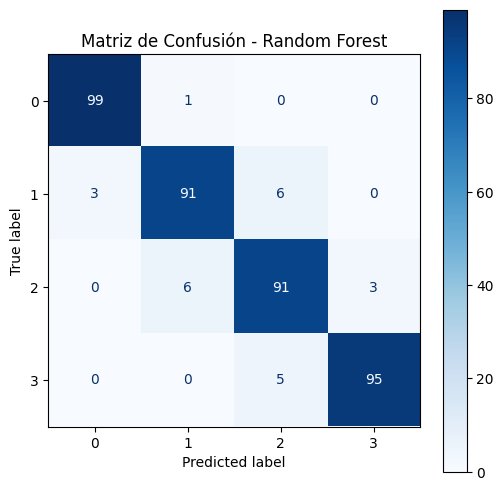

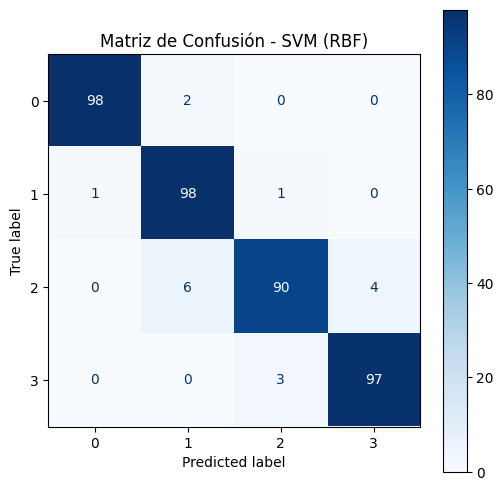

In [11]:
modelo_rf.fit(X_train_selected, y_train)
y_pred_rf = modelo_rf.predict(X_test_seleccionado)

modelo_svm.fit(X_train_selected, y_train)
y_pred_svm = modelo_svm.predict(X_test_seleccionado)

print("--- MÉTRICAS OBLIGATORIAS EN TEST  (Usando 4 mejores datos) ---")

# Accuracy
precision_final_rf = accuracy_score(y_test, y_pred_rf)
precision_final_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión final en el conjunto de prueba --> Random Forest: {precision_final_rf * 100:.2f}")
print(f"Precisión final en el conjunto de prueba --> SVM (RBF): {precision_final_svm * 100:.2f}\n")


# Informes de Clasificación (Incluyen Precision, Recall, F1 y los promedios macro/weighted)
report_final_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_final_svm = classification_report(y_test, y_pred_svm, output_dict=True)

print('Report de RANDOM FOREST:')
df_rf = pd.DataFrame(report_final_rf).transpose()
display(df_rf.round(2))

print('Report de Accuracy SVM (RBF):')
df_svm = pd.DataFrame(report_final_svm).transpose()
display(df_svm.round(2))

# Matrices de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rangos)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=rangos)


# Graficamos las matrices
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
disp_svm.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - SVM (RBF)')
plt.show()

## **Conclusiones Generales**

Añada una celda de texto final comparando los resultados obtenidos con los diferentes modelos, y extraiga conclusiones sobre si hay alguno mejor que otro en función del número de parámetros requerido, la precisión, etc.

Tras evaluar y enfrentar los modelos Random Forest y SVM con Kernel RBF para predecir la gama de precios de los móviles, extraemos las siguientes conclusiones:<br><br>
1.   **Estabilidad durante la Validación Cruzada**<br>
Durante la fase de entrenamiento con validación cruzada, observamos que a pesar de que el Random Forest obtuvo una media de precisión inicial un poco superior (86.31% frente al 85.75% del SVM), el SVM demostró ser un modelo mucho más estable y robusto. La desviación estándar del SVM fue de apenas +/- 0.0100, un tercio de la mostrada por el Random Forest (+/- 0.0301). Esto nos indicaba ya que el SVM era menos sensible a las particiones de los datos y prometía una generalización más consistente.

2. **Rendimiento Final en Test de ambos modelos**<br>
Al enfrentar los modelos a los datos de prueba definitivos, el SVM (RBF) confirma su superioridad, alcanzando una precisión final del 89.50% (0.90 en el reporte general), superando el 88.00% del Random Forest.<br>
Si desglosamos el reporte por clases, detectamos exactamente dónde gana el SVM:
En los extremos, en la clase 0 y clase 3, ambos modelos lo hacen muy bien, con métricas F1-score por encima del 0.92.
El problema viene en los móviles de clases intermedias 1 y 2, aquí el Random Forest sufre con F1-scores de 0.83 y 0.80, mientras que el SVM tiene valores mucho más precisos de 0.87 y 0.84. Esto se debe a que Random Forest intenta separar los móviles usando divisiones rectas y rígidas, en cambio SVM funciona mucho mejor porque dibuja fronteras curvas y flexibles, centrando todo su esfuerzo justo en los puntos límite donde las dos gamas se mezclan.

3.   **Resultados con las 4 Mejores Variables**
Tras aplicar SelectKBest y entrenar los modelos utilizando únicamente las 4 características más relevantes (ram, battery_power, px_height, px_width), los resultados obtenidos son excepcionales. La precisión final ha aumentado: Random Forest con 94.00% y SVM con 95.75%.<br>
Esto se debe a que hemos eliminado variables que realmente no ayudan a predecir, lo que hacen es confundir al modelo, por eso al eliminarlas han mejorado los resultados. La gran mejora es en las clases intermedias (1 y 2) comentadas anteriormente, ahora obtenemos valores por encima de 0.90 en ambos modelos.

4. **Número de Parámetros (Complejidad)**<br>
Random Forest: Tiene muchísimos parámetros porque memoriza la estructura y las divisiones exactas de cientos de árboles de decisión.<br>
SVM: Tiene muy pocos parámetros porque, una vez entrenado, solo necesita memorizar las posiciones de unos cuantos casos límite para dibujar la curva que separa las clases.
5. **Conclusión final**<br>
La conclusión final es que entre los dos modelos el mejor en este caso es SVM ya que logra mayor precisión y estabilidad, además de ser más eficiente que Random Forest. <br>
Al quedarnos con las 4 características más relevantes, hemos visto que los modelos son más rápidos, precisos y eficientes, esto nos dice que tener más datos no siempre es mejor, es mucho más importante tener variables de calidad, aunque sean pocas.


---

# **Ejercicio 2: Problema de Regresión (5 puntos)**

## 2.1 Contexto: Predicción de la Resistencia del Hormigón

En ingeniería civil, la resistencia a la compresión del hormigón es una función compleja de su edad y sus ingredientes. En este ejercicio, deberá desarrollar un modelo de regresión para **predecir la resistencia (en MegaPascales, MPa)** basándose en la composición de la mezcla.

**Dataset:** Concrete Compressive Strength Data Set (UCI Machine Learning Repository).

- **Variables de Entrada (X):** Cemento, Escoria, Ceniza, Agua, Superplastificante, Árido grueso, Árido fino, Edad (días).
- **Variable de Salida (Y):** Resistencia a la compresión del hormigón (MPa).


In [12]:
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor


# Carga de datos Regresión
url= 'https://drive.google.com/file/d/1mlzSDAUlXMMTjL7PbpXJQddHKAyZeYft/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]

df_reg = pd.read_csv(url)

print("Datos de Regresión cargados:")
display(df_reg.head())

Datos de Regresión cargados:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.2 Análisis y Preprocesado (Regresión)

Prepare los datos para el modelado:
1.  Estudie la distribución de la variable objetivo (`strength`).
2.  Analice la correlación de las variables de entrada con la salida.
3.  Aplique el escalado necesario a las variables independientes.

1.  Estudie la distribución de la variable objetivo (`strength`).

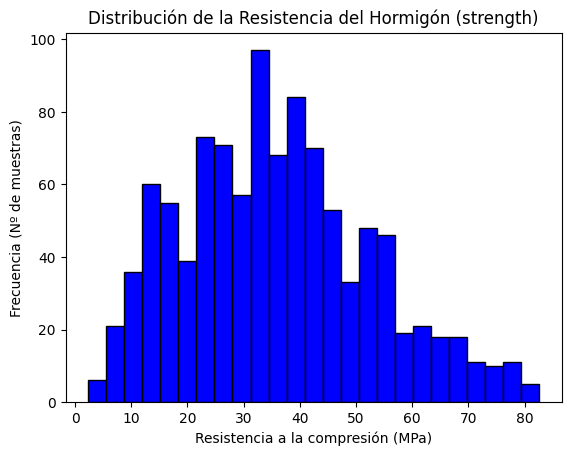

In [13]:
df_reg['strength'].hist(bins=25, color='blue', edgecolor='black')
plt.title('Distribución de la Resistencia del Hormigón (strength)')
plt.xlabel('Resistencia a la compresión (MPa)')
plt.ylabel('Frecuencia (Nº de muestras)')
plt.grid(False) # Quitar la cuadrícula
plt.show()

2.  Analice la correlación de las variables de entrada con la salida.

In [14]:
matriz_corr = df_reg.corr() # Obtenemos la matriz de correlación
corr_strength = matriz_corr['strength'].sort_values(ascending = False)
print(corr_strength)

strength        1.000000
cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64


A diferencia del ejercicio de clasificación aquí no tenemos un dato con una correlación muy alta, como sucedia con la RAM, sin embargo tenemos que todos los datos tienen una correlación mayor a 0.1, por lo tanto nos serviran todos.

3.  Aplique el escalado necesario a las variables independientes.

Para ello primero nos quedamos con todos los datos en bruto y tambien por separado con los datos de Resistencia a la compresion (MPa)



In [15]:
X_reg_raw = df_reg.drop(columns=['strength']).values   # Nos quedamos con todos los datos en bruto quitando strength
Y_reg_raw = df_reg['strength'].values
print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))

Dimensiones de X: 2000 datos y 20 atributos/dato


Ahora separamos los datos de la siguiente forma 20% para tests y 80% para entrenamiento

In [16]:
# Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
# Hacemos esto ANTES del escalado para evitar fuga de información (data leakage)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_raw, Y_reg_raw, test_size=0.2, random_state=42)


Ahora sí vamos a proceder al escalado de datos

In [17]:
# Estandarización de datos
scaler = StandardScaler()
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test) # Transformamos test con los parámetros de train

## 2.3 Modelado y Evaluación (Regresión)

Entrene al menos 2 modelos de regresión (ej. Regresión Lineal, SVR, Gradient Boosting...).

**Métricas obligatorias:**
- MSE (Mean Squared Error)
- R2 Score (Coeficiente de determinación)
- MAE (Mean Absolute Error)

Incluya una gráfica de dispersión: Valores Reales (eje X) vs Valores Predichos (eje Y).

METRICAS LINEAR REGRESSION:

La métrica MSE tiene un valor de 95.97094009110677
La métrica R2 tiene un valor de 0.6275531792314851
La métrica MAE tiene un valor de 7.745559243921431

METRICAS GRADIENT BOOSTING:

La métrica MSE tiene un valor de 30.176898188589746
La métrica R2 tiene un valor de 0.8828886141958622
La métrica MAE tiene un valor de 4.135014150874571




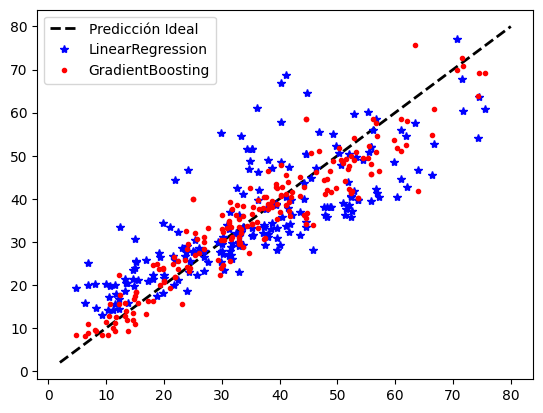

In [18]:
# DEFINIMOS Y ENTRENAMOS LOS MODELOS
modelo_lr = LinearRegression()
modelo_gb = GradientBoostingRegressor(random_state=42)

# ENTRENAMOS
modelo_lr.fit(X_reg_train, y_reg_train)
modelo_gb.fit(X_reg_train, y_reg_train)

# HACEMOS LAS PREDICCIONES
y_pred_lr = modelo_lr.predict(X_reg_test)
y_pred_gb = modelo_gb.predict(X_reg_test)


# Mostrar las métricas
metricas= {
    'MSE' : mean_squared_error,
    'R2'  : r2_score,
    'MAE' : mean_absolute_error
}
print('METRICAS LINEAR REGRESSION:\n')
for metrica in metricas:
  f_metrica= metricas[metrica]
  valor= f_metrica(y_true= y_reg_test, y_pred= y_pred_lr)
  print('La métrica {} tiene un valor de {}'.format(metrica, valor))

print('\nMETRICAS GRADIENT BOOSTING:\n')
for metrica in metricas:
  f_metrica= metricas[metrica]
  valor= f_metrica(y_true= y_reg_test, y_pred= y_pred_gb)
  print('La métrica {} tiene un valor de {}'.format(metrica, valor))
print('\n')


# Grafica (esto es para poner una linea x=y que muestra el valor real)
plt.plot([2,80], [2,80], 'k--', lw=2, label='Predicción Ideal (x=y)')
# Mostramos datos reales vs predichos para ver si se corresponden
plt.plot(y_reg_test, y_pred_lr, 'b*') # Línea base
plt.plot(y_reg_test, y_pred_gb, 'r.') # Línea base
plt.legend(['Predicción Ideal', 'LinearRegression', 'GradientBoosting'])
plt.show()

**Cambiando hiperparámetros**<br>
Como decía en las diapositivas que cambiaramos algunos hiperparámetros, ahora vamos a cambiar algunos de los hiperparámetros del modelo Gradient Boosting. Modificaremos n_estimators, que define el número total de árboles de decisión que el algoritmo construirá secuencialmente, donde cada nuevo árbol se encarga de calcular y corregir el error matemático que dejaron los anteriores.


METRICAS GRADIENT BOOSTING (n_estimators = 2500):

La métrica MSE tiene un valor de 18.593375349521004
La métrica R2 tiene un valor de 0.9278422871578551
La métrica MAE tiene un valor de 2.713906149027507




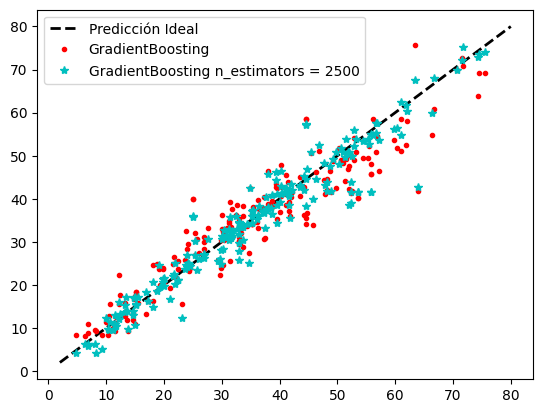

In [19]:
# DEFINIMOS Y ENTRENAMOS LOS MODELOS
modelo_gb_n_est = GradientBoostingRegressor(n_estimators = 2500, random_state=42)

# ENTRENAMOS
modelo_gb_n_est.fit(X_reg_train, y_reg_train)

# HACEMOS LAS PREDICCIONES
y_pred_gb_n_est = modelo_gb_n_est.predict(X_reg_test)


# Mostrar las métricas
metricas= {
    'MSE' : mean_squared_error,
    'R2'  : r2_score,
    'MAE' : mean_absolute_error
}

print('\nMETRICAS GRADIENT BOOSTING (n_estimators = 2500):\n')
for metrica in metricas:
  f_metrica= metricas[metrica]
  valor= f_metrica(y_true= y_reg_test, y_pred= y_pred_gb_n_est)
  print('La métrica {} tiene un valor de {}'.format(metrica, valor))
print('\n')


# Grafica (esto es para poner una linea x=y que muestra el valor real)
plt.plot([2,80], [2,80], 'k--', lw=2, label='Predicción Ideal (x=y)')
# Mostramos datos reales vs predichos para ver si se corresponden
# Comparacion con el resultado anterior
plt.plot(y_reg_test, y_pred_gb, 'r.') # Línea base
plt.plot(y_reg_test, y_pred_gb_n_est, 'c*') # Línea base
plt.legend(['Predicción Ideal', 'GradientBoosting', 'GradientBoosting n_estimators = 2500'])
plt.show()

---

## **Conclusiones Generales**

Añada una celda de texto final comparando los resultados obtenidos con los diferentes modelos, y extraiga conclusiones sobre si hay alguno mejor que otro en función del número de parámetros requerido, la precisión, etc.

**Conclusiones:**

1. **Comparación de resultados en ambos modelos**<br>
En los resultados obtenidos vemos que el error absoluto y el cuadrático (MAE y MSE) son mucho menores en Gradient Boosting, y que el coeficiente de determinación R2 es mucho mayor que en Regresión Lineal, siendo 0.62 en este y en Gradient Boosting de 0.88. Todo esto se puede ver visualmente en las gráficas mostradas, donde claramente los puntos rojos de Gradient Boosting se ajustan mucho mejor a los valores reales de la recta x=y que las estrellas azules de Regresión Lineal.<br>
Esto se debe a que la resistencia del hormigón es un proceso químico complejo donde existen relaciones no lineales e interacciones fuertes entre los ingredientes. El Gradient Boosting, al ser un modelo ensamblado (basado en múltiples árboles de decisión construidos secuencialmente), es capaz de capturar estos "patrones ocultos" y relaciones químicas complejas.

2. **Comparación complejidad**<br>
En el Gradient Boosting el número de parámetros y complejidad interna son muchísimo mayor que en el Lineal. Sin embargo, aunque con esto perdemos la interpretabilidad matemática directa que nos ofrecía la Regresión Lineal, este aumento de complejidad está totalmente justificado, ya que en este ámbito de la construcción es esencial tener buenas predicciones.

3. **Hiperparámetros en Gradient Boosting**
El hiperparámetro n_estimators define el número total de árboles de decisión que el algoritmo construirá secuencialmente, donde cada nuevo árbol se encarga de calcular y corregir el error matemático que dejaron los anteriores.
Al comparar el rendimiento del Gradient Boosting con su configuración por defecto frente a una versión con n_estimators = 2500, observamos una mejora en el rendimiento, donde: <br>
- El error absoluto (MAE) se reduce de 4.13 a 2.71. <br>
- El error cuadrático (MSE) se reduce de 30.17 a 18.59.<br>
- El coeficiente de determinación (R2) sube de 0.88 a 0.93.<br>
Esto se debe a que el modelo por defecto usa n_estimators = 100, y nosotros en el otro hemos puesto n_estimators = 2500. Aunque usar 2500 árboles alcanza una precisión matemática superior al afinar cada detalle, en la práctica suele ser mejor quedarse con 100 porque capta la esencia del problema de forma eficiente y rápida. Sin embargo, abusar de este parámetro y poner un valor muy grande, arruinaría el modelo provocando sobreajuste (overfitting), ya que el algoritmo dejaría de aprender para empezar a memorizar "ruido" inútil y colapsaría computacionalmente.

4. **Conclusión final**<br>
Queda claro que, entre ambos algoritmos, el Gradient Boosting es la mejor opción para este problema. A pesar de ser más costoso computacionalmente, su superioridad predictiva justifica totalmente su uso. <br>
En cuanto a los hiperparámetros, la moderación es clave: es mejor buscar un equilibrio con valores conservadores para obtener una buena precisión sin caer en el sobreajuste.
